In [1]:
from ipywidgets import widgets
from fastai.vision.all import *

In [10]:
path = untar_data(URLs.PETS)/'images'

In [ ]:
def is_cat(x): return x[0].isupper() #serve per creare automaticamente le etichette di classificazione
                                     #usa la maiuscula inziale per capire se l'immagine appartiene alla categoria "cat"
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224)) #serve a preparare automaticamente i dati immagini per il training di un modello di deep learning. 
                                              #legge le immagini
                                              #le divide in set di training e validazione (20% per validazione)
                                              #applica una trasformazione di ridimensionamento a 224x224 pixel
                                              #utilizza la funzione is_cat per creare le etichette di classificazione basate sui nomi dei file delle immagini
                                              #prepara i dati per essere utilizzati in un modello di deep learning
    #valid_pct=0.2 : indica a fastai di tenere da parte il 20% dei dati e di non utilizzarli affatto per addestrare il modello.
    # Il 20% dei dati viene chiamato set di validazione; il restante 80% viene chiamato set di addestramento.
    # seed=42 imposta il seed casuale allo stesso valore ogni volta che eseguiamo questo codice, il che significa che otteniamo lo stesso set di validazione ogni volta.
    # In questo modo, se modifichiamo il nostro modello e lo riaddestriamo, 
    # sappiamo che eventuali differenze sono dovute alle modifiche apportate al modello e non all'utilizzo di un diverso set di validazione casuale.                                          
learn = vision_learner(dls, resnet34, metrics=error_rate) #serve a creare un modello di deep learning per la classificazione delle immagini utilizzando la libreria fastai.
learn.fine_tune(1) #serve a eseguire il fine-tuning del modello per 1 epoch, adattando un modello pre-addestrato (resnet34) ai dati specifici del set di immagini di gatti e cani.


epoch,train_loss,valid_loss,error_rate,time
0,0.179958,0.020274,0.006089,04:20


epoch,train_loss,valid_loss,error_rate,time
0,0.049542,0.012951,0.006089,05:52


In [15]:
uploader = widgets.FileUpload()
uploader

FileUpload(value=(), description='Upload')

Is this a cat?: True.
Probability it's a cat: 1.000000


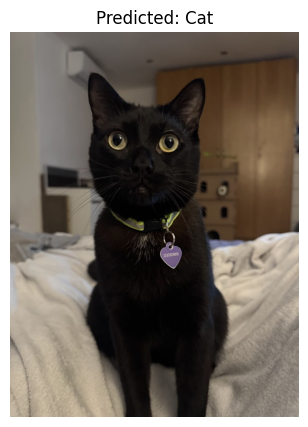

In [ ]:
uploaded = uploader.value[0] if isinstance(uploader.value, tuple) else next(iter(uploader.value.values()))
img = PILImage.create(uploaded['content'].tobytes() if hasattr(uploaded['content'], 'tobytes') else uploaded['content'])
is_cat,_,probs = learn.predict(img)
img.show(title=f"Predicted: {'Cat' if is_cat == "True" else 'Not Cat'}")
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")
#Questo modello fa una previsione su un'immagine caricata dall'utente, mostrando se è un gatto o no, e la probabilità associata alla previsione.
# Si basa però solo su immagini di gatti e cani, quindi potrebbe non essere accurato per altre categorie di immagini. 
# Perchè forza uno dei due risultati (cat o not cat) anche se l'immagine potrebbe essere di un'altra categoria.